<a href="https://colab.research.google.com/github/Amika1118/DSGP_Group_38/blob/Market-Price-Prediction/final_feature_engineering_before_training_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%cd /content
!git clone https://github.com/Amika1118/DSGP_Group_38.git
%cd DSGP_Group_38

/content
Cloning into 'DSGP_Group_38'...
remote: Enumerating objects: 146, done.
remote: Counting objects: 100% (146/146), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 146 (delta 50), reused 76 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (146/146), 9.72 MiB | 16.62 MiB/s, done.
Resolving deltas: 100% (50/50), done.
/content/DSGP_Group_38


In [2]:
!git checkout Market-Price-Prediction

Branch 'Market-Price-Prediction' set up to track remote branch 'Market-Price-Prediction' from 'origin'.
Switched to a new branch 'Market-Price-Prediction'


In [3]:
!git config --global user.name "Lasani Layathma"
!git config --global user.email "lasani.20241357@iit.ac.lk"

In [4]:
from getpass import getpass
token = getpass("Enter GitHub token: ")
!git remote set-url origin https://{token}@github.com/Amika1118/DSGP_Group_38.git


Enter GitHub token: ··········


In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv('/content/historical_data_preprocessed (1).csv')
df['Start_Date'] = pd.to_datetime(df['Start_Date'])

print(f"Original shape: {df.shape}")
print(f"Original columns: {len(df.columns)}")
print(f"First few rows:\n{df[['Year', 'Month', 'Variety_encoded', 'Is_BITTER_GOURD', 'Is_BRINJALS', 'Is_PUMPKIN', 'Is_TOMATOES', 'Is_CABBAGE', 'Is_CARROT']].head()}")


Original shape: (7784, 62)
Original columns: 62
First few rows:
   Year  Month  Variety_encoded  Is_BITTER_GOURD  Is_BRINJALS  Is_PUMPKIN  \
0  2000      1                0                1            0           0   
1  2000      1                0                1            0           0   
2  2000      1                0                1            0           0   
3  2000      1                0                1            0           0   
4  2000      1                0                1            0           0   

   Is_TOMATOES  Is_CABBAGE  Is_CARROT  
0            0           0          0  
1            0           0          0  
2            0           0          0  
3            0           0          0  
4            0           0          0  


In [6]:
# IDENTIFY VEGETABLE TYPE FROM ONE-HOT ENCODED COLUMNS
def identify_vegetable(row):
    """Extract vegetable name from one-hot encoded columns"""
    veg_columns = ['Is_BITTER_GOURD', 'Is_BRINJALS', 'Is_PUMPKIN', 'Is_TOMATOES', 'Is_CABBAGE', 'Is_CARROT']

    # Check if any of these columns exist
    existing_veg_cols = [col for col in veg_columns if col in row.index]

    if not existing_veg_cols:
        return 'UNKNOWN'

    # Find which vegetable has value 1
    for col in existing_veg_cols:
        if row[col] == 1:
            # Extract vegetable name from column name
            return col.replace('Is_', '').replace('_', ' ').title()

    return 'UNKNOWN'

# Add vegetable name column
df['Vegetable'] = df.apply(identify_vegetable, axis=1)

# Check vegetable distribution
print(f"\nVegetable distribution:")
print(df['Vegetable'].value_counts())

# Also map encoded values to names for consistency
vegetable_mapping = {
    0: 'BITTER GOURD',  # Based on the data, Variety_encoded=0 appears to be BITTER GOURD
    # Add other mappings if you have them
}
if 'Variety_encoded' in df.columns:
    df['Vegetable_From_Encoded'] = df['Variety_encoded'].map(vegetable_mapping)
    print(f"\nVegetable from encoded column:")
    print(df['Vegetable_From_Encoded'].value_counts())


Vegetable distribution:
Vegetable
Bitter Gourd    1306
Brinjals        1306
Cabbage         1306
Pumpkin         1306
Tomatoes        1306
Carrot          1254
Name: count, dtype: int64

Vegetable from encoded column:
Vegetable_From_Encoded
BITTER GOURD    1306
Name: count, dtype: int64


In [7]:
# SAFELY REMOVE UNNECESSARY COLUMNS
def safe_drop_columns(df, columns_to_drop):
    """Safely drop columns if they exist"""
    existing_cols = [col for col in columns_to_drop if col in df.columns]
    print(f"Dropping columns: {existing_cols}")
    return df.drop(columns=existing_cols)

# List of columns to potentially remove
columns_to_remove = [
    'End_Date',  # Redundant with Start_Date
    'Month_Year',  # Redundant with Year+Month
    'Days_In_Week',  # Mostly constant
    'Manual_Rolling_Mean_4w',  # If it exists and is duplicate
    'Manual_Rolling_Mean_4w_scaled',  # If it exists
]

# Also remove individual Is_* columns (we already extracted vegetable name)
veg_cols = [col for col in df.columns if col.startswith('Is_')]
columns_to_remove.extend(veg_cols)

df = safe_drop_columns(df, columns_to_remove)
print(f"\nAfter removing redundant columns: {df.shape}")

Dropping columns: ['End_Date', 'Month_Year', 'Days_In_Week', 'Manual_Rolling_Mean_4w', 'Manual_Rolling_Mean_4w_scaled', 'Is_BITTER_GOURD', 'Is_BRINJALS', 'Is_PUMPKIN', 'Is_TOMATOES', 'Is_CABBAGE', 'Is_CARROT']

After removing redundant columns: (7784, 53)


In [8]:

# CREATE OPTIMIZED FEATURE SET (FIXED VERSION)
def create_optimized_features_safe(df):
    """Create optimized feature set with safe column checks"""

    # VEGETABLE IDENTIFICATION FEATURES (MUST KEEP)
    vegetable_features = []
    if 'Variety_encoded' in df.columns:
        vegetable_features.append('Variety_encoded')
    if 'Vegetable' in df.columns:
        vegetable_features.append('Vegetable')

    # CORE FEATURES - Check each one exists
    possible_core_features = [
        # Lag features
        'Weekly_Price_lag1', 'Weekly_Price_lag2', 'Weekly_Price_lag3',

        # Rolling statistics
        'Rolling_Mean_4w', 'Rolling_Std_4w', 'Rolling_Mean_13w',

        # Price momentum
        'Price_Change_lag1', 'Price_Change_Pct_lag1',

        # External factors
        'Fuel_Price',

        # Temporal features
        'Month_Sin', 'Month_Cos', 'Day_of_Year',

        # Ratios
        'Price_to_Fuel_Ratio', 'Price_to_Rolling_Mean_Ratio',

        # Categorical encodings
        'Location_encoded', 'Season_encoded', 'Quarter_encoded'
    ]

    # Keep only features that actually exist
    core_features = [f for f in possible_core_features if f in df.columns]

    print(f"\nFound {len(core_features)}/{len(possible_core_features)} core features")

    # NEW ENGINEERED FEATURES
    df_opt = df.copy()

    # Check prerequisites before creating new features
    try:
        # 1. Price Acceleration
        if 'Price_Change_lag1' in df_opt.columns and 'Price_Change_lag2' in df_opt.columns:
            df_opt['Price_Acceleration'] = df_opt['Price_Change_lag1'] - df_opt['Price_Change_lag2']
            print("Created: Price_Acceleration")
    except Exception as e:
        print(f"Could not create Price_Acceleration: {e}")

    try:
        # 2. Volatility Regime
        if 'Price_Std' in df_opt.columns:
            df_opt['High_Volatility_Regime'] = (
                df_opt['Price_Std'] > df_opt['Price_Std'].rolling(13, min_periods=1).mean()
            ).astype(int)
            print("Created: High_Volatility_Regime")
    except Exception as e:
        print(f"Could not create High_Volatility_Regime: {e}")

    try:
        # 3. Momentum Indicator
        if 'Price_Change_lag1' in df_opt.columns and 'Price_Change_lag2' in df_opt.columns:
            df_opt['Positive_Momentum'] = (
                (df_opt['Price_Change_lag1'] > 0) &
                (df_opt['Price_Change_lag2'] > 0)
            ).astype(int)
            print("Created: Positive_Momentum")
    except Exception as e:
        print(f"Could not create Positive_Momentum: {e}")

    try:
        # 4. Relative Position in Range
        if 'Weekly_Price' in df_opt.columns and 'Rolling_Mean_4w' in df_opt.columns:
            rolling_min = df_opt['Rolling_Mean_4w'].rolling(4, min_periods=1).min()
            rolling_max = df_opt['Rolling_Mean_4w'].rolling(4, min_periods=1).max()
            df_opt['Price_Position_4w'] = (
                (df_opt['Weekly_Price'] - rolling_min) /
                (rolling_max - rolling_min + 1e-10)
            )
            print("Created: Price_Position_4w")
    except Exception as e:
        print(f"Could not create Price_Position_4w: {e}")

    try:
        # 5. Fuel Impact Ratio
        if 'Price_Change_Pct' in df_opt.columns and 'Fuel_Price' in df_opt.columns:
            df_opt['Fuel_Impact_Ratio'] = df_opt['Price_Change_Pct'] / (df_opt['Fuel_Price'] + 1e-10)
            print("Created: Fuel_Impact_Ratio")
    except Exception as e:
        print(f"Could not create Fuel_Impact_Ratio: {e}")

    try:
        # 6. Trend Consistency
        if 'Price_Change' in df_opt.columns:
            df_opt['Trend_Consistency'] = (
                (df_opt['Price_Change'] > 0).rolling(3, min_periods=1).mean().shift(1)
            )
            print("Created: Trend_Consistency")
    except Exception as e:
        print(f"Could not create Trend_Consistency: {e}")

    try:
        # 7. Vegetable-specific price deviation
        if 'Vegetable' in df_opt.columns and 'Weekly_Price' in df_opt.columns:
            # Calculate average price per vegetable
            veg_avg_price = df_opt.groupby('Vegetable')['Weekly_Price'].transform('mean')
            df_opt['Price_Deviation_From_Veg_Avg'] = df_opt['Weekly_Price'] - veg_avg_price
            print("Created: Price_Deviation_From_Veg_Avg")
    except Exception as e:
        print(f"Could not create Price_Deviation_From_Veg_Avg: {e}")

    try:
        # 8. Seasonal price index
        if 'Season_encoded' in df_opt.columns and 'Weekly_Price' in df_opt.columns:
            season_avg_price = df_opt.groupby('Season_encoded')['Weekly_Price'].transform('mean')
            overall_avg_price = df_opt['Weekly_Price'].mean()
            df_opt['Seasonal_Price_Index'] = season_avg_price / overall_avg_price
            print("Created: Seasonal_Price_Index")
    except Exception as e:
        print(f"Could not create Seasonal_Price_Index: {e}")

    # List of newly created features (check if they exist)
    new_features = [
        'Price_Acceleration', 'High_Volatility_Regime', 'Positive_Momentum',
        'Price_Position_4w', 'Fuel_Impact_Ratio', 'Trend_Consistency',
        'Price_Deviation_From_Veg_Avg', 'Seasonal_Price_Index'
    ]
    existing_new_features = [f for f in new_features if f in df_opt.columns]

    # Combine all features
    all_features = vegetable_features + core_features + existing_new_features

    # Also include some important scaled features if they exist
    scaled_to_consider = [
        'Rolling_Mean_4w_scaled', 'Rolling_Std_4w_scaled',
        'Fuel_Price_scaled'
    ]
    existing_scaled = [f for f in scaled_to_consider if f in df_opt.columns]
    all_features.extend(existing_scaled)

    # Remove duplicates
    all_features = list(dict.fromkeys(all_features))

    # Display summary
    print(f"\n{'='*60}")
    print("OPTIMIZED FEATURE SET:")
    print(f"{'='*60}")
    print(f"Total features: {len(all_features)}")
    print(f"Vegetable features: {vegetable_features}")

    # Categorize features
    categories = {
        'Vegetable Info': [f for f in all_features if 'vegetable' in f.lower() or 'variety' in f.lower()],
        'Lag & History': [f for f in all_features if 'lag' in f.lower()],
        'Rolling Stats': [f for f in all_features if 'rolling' in f.lower() or 'mean' in f.lower() or 'std' in f.lower() or 'position' in f.lower()],
        'Price Dynamics': [f for f in all_features if 'change' in f.lower() or 'acceleration' in f.lower() or 'trend' in f.lower() or 'momentum' in f.lower() or 'deviation' in f.lower()],
        'Temporal/Seasonal': [f for f in all_features if 'month' in f.lower() or 'day' in f.lower() or 'year' in f.lower() or 'week' in f.lower() or 'quarter' in f.lower() or 'season' in f.lower()],
        'External Factors': [f for f in all_features if 'fuel' in f.lower() or 'ratio' in f.lower() or 'impact' in f.lower()],
        'Location/Geography': [f for f in all_features if 'location' in f.lower()],
        'New Engineered': existing_new_features,
    }

    for category, features in categories.items():
        if features:
            print(f"\n{category.upper()} ({len(features)}):")
            for feat in features:
                print(f"  • {feat}")

    return df_opt, all_features

# Create optimized features
df_optimized, optimal_features = create_optimized_features_safe(df)


Found 17/17 core features
Created: Price_Acceleration
Created: High_Volatility_Regime
Created: Positive_Momentum
Created: Price_Position_4w
Created: Fuel_Impact_Ratio
Created: Trend_Consistency
Created: Price_Deviation_From_Veg_Avg
Created: Seasonal_Price_Index

OPTIMIZED FEATURE SET:
Total features: 30
Vegetable features: ['Variety_encoded', 'Vegetable']

VEGETABLE INFO (2):
  • Variety_encoded
  • Vegetable

LAG & HISTORY (5):
  • Weekly_Price_lag1
  • Weekly_Price_lag2
  • Weekly_Price_lag3
  • Price_Change_lag1
  • Price_Change_Pct_lag1

ROLLING STATS (7):
  • Rolling_Mean_4w
  • Rolling_Std_4w
  • Rolling_Mean_13w
  • Price_to_Rolling_Mean_Ratio
  • Price_Position_4w
  • Rolling_Mean_4w_scaled
  • Rolling_Std_4w_scaled

PRICE DYNAMICS (6):
  • Price_Change_lag1
  • Price_Change_Pct_lag1
  • Price_Acceleration
  • Positive_Momentum
  • Trend_Consistency
  • Price_Deviation_From_Veg_Avg

TEMPORAL/SEASONAL (9):
  • Weekly_Price_lag1
  • Weekly_Price_lag2
  • Weekly_Price_lag3
  • Mo


ANALYZING FEATURE IMPORTANCE

Encoding categorical columns: ['Vegetable']
Filling missing values in: ['Trend_Consistency']

Training Random Forest on 7784 samples, 34 features...


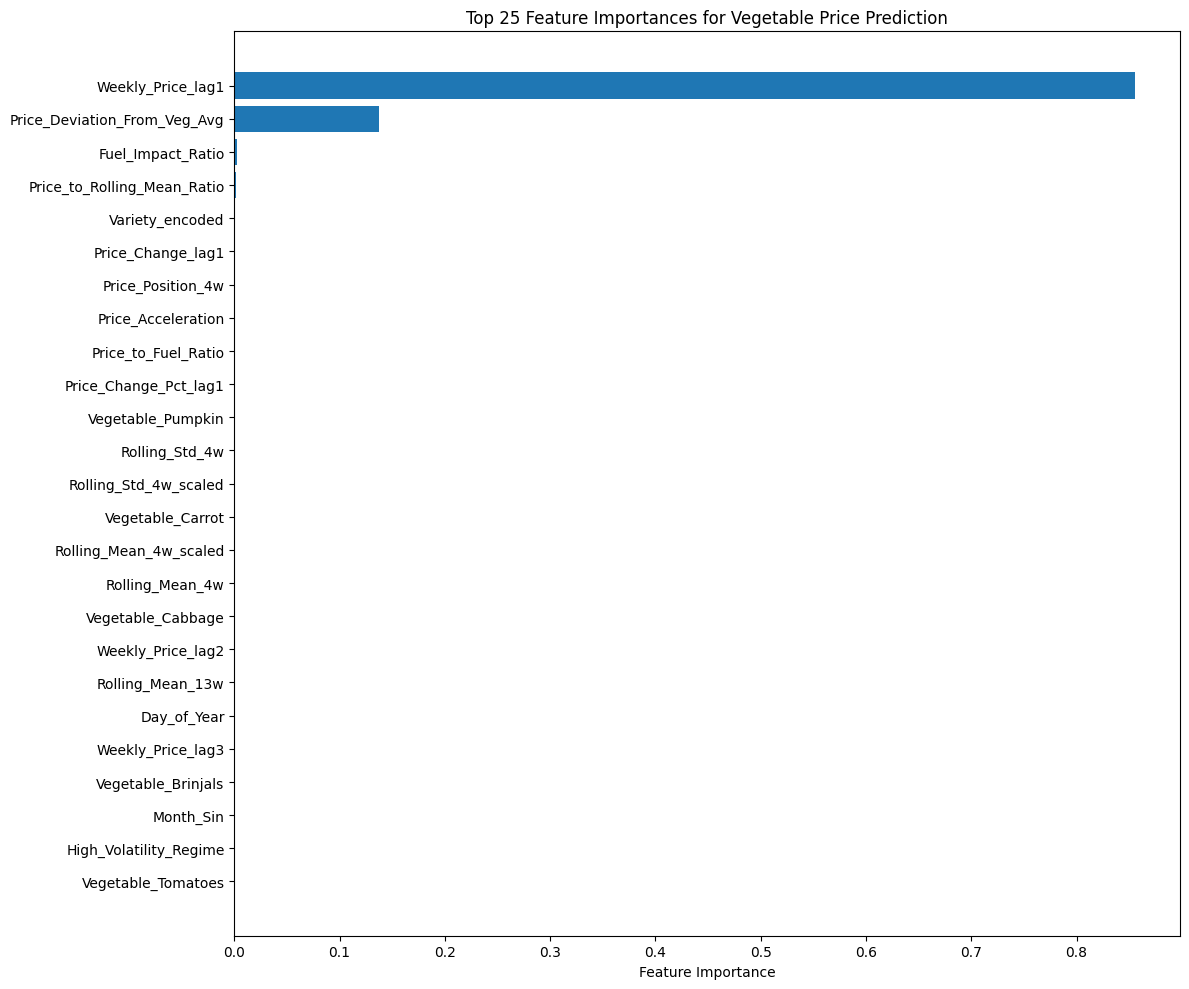

FEATURE IMPORTANCE SUMMARY:
Most important feature: Weekly_Price_lag1 (0.855)
Least important feature: Location_encoded (0.000)

Low importance features (bottom 30%, 10 features):
   1. Vegetable_Tomatoes: 0.00002
   2. Month_Cos: 0.00002
   3. Fuel_Price_scaled: 0.00002
   4. Fuel_Price: 0.00001
   5. Seasonal_Price_Index: 0.00001
   6. Season_encoded: 0.00001
   7. Quarter_encoded: 0.00001
   8. Trend_Consistency: 0.00001
   9. Positive_Momentum: 0.00000
  10. Location_encoded: 0.00000


In [9]:
# FEATURE IMPORTANCE ANALYSIS (SAFE VERSION)
def analyze_feature_importance_safe(df, feature_list):
    """Safe feature importance analysis"""

    # Use only historical data for training
    historical_mask = df['Data_Type'] == 'Historical'
    if historical_mask.sum() == 0:
        print("No historical data found!")
        return None, None

    # Prepare feature matrix - need to handle categorical columns
    X_raw = df.loc[historical_mask, feature_list].copy()
    y = df.loc[historical_mask, 'Weekly_Price']

    # Convert categorical columns to numerical
    X = X_raw.copy()
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns

    if len(categorical_cols) > 0:
        print(f"\nEncoding categorical columns: {list(categorical_cols)}")
        X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    # Check for missing values
    missing_cols = X.columns[X.isnull().any()].tolist()
    if missing_cols:
        print(f"Filling missing values in: {missing_cols}")
        X = X.fillna(X.median())

    # Train model
    print(f"\nTraining Random Forest on {len(X)} samples, {len(X.columns)} features...")
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X, y)

    # Get feature importance
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    # Plot top features
    plt.figure(figsize=(12, 10))
    top_n = min(25, len(importance_df))
    top_features = importance_df.head(top_n)

    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'Top {top_n} Feature Importances for Vegetable Price Prediction')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # Identify low importance features (bottom 30%)
    threshold = importance_df['importance'].quantile(0.3)
    low_importance = importance_df[importance_df['importance'] < threshold]['feature'].tolist()

    print("FEATURE IMPORTANCE SUMMARY:")
    print(f"Most important feature: {importance_df.iloc[0]['feature']} ({importance_df.iloc[0]['importance']:.3f})")
    print(f"Least important feature: {importance_df.iloc[-1]['feature']} ({importance_df.iloc[-1]['importance']:.3f})")

    print(f"\nLow importance features (bottom 30%, {len(low_importance)} features):")
    for i, feat in enumerate(low_importance[:20], 1):
        importance_val = importance_df[importance_df['feature'] == feat]['importance'].values[0]
        print(f"  {i:2d}. {feat}: {importance_val:.5f}")

    return importance_df, low_importance, model

# Analyze feature importance
print(f"\n{'='*60}")
print("ANALYZING FEATURE IMPORTANCE")
print(f"{'='*60}")
importance_df, low_importance, rf_model = analyze_feature_importance_safe(df_optimized, optimal_features)

In [10]:
# CREATE FINAL OPTIMIZED DATASET WITH VEGETABLE COLUMN
def create_final_dataset(df, feature_list, remove_low_importance=None):
    """Create final optimized dataset with vegetable information"""

    # Keep only important features
    if remove_low_importance is not None:
        # Map one-hot encoded feature names back to original features
        original_features_to_remove = []
        for feature in remove_low_importance:
            # Check if it's a one-hot encoded feature
            if 'Vegetable_' in feature:
                # Keep the original vegetable column
                continue
            elif any(col in feature for col in ['Location_encoded', 'Season_encoded', 'Quarter_encoded']):
                # These might be one-hot encoded, keep original
                base_col = feature.split('_')[0] + '_encoded'
                if base_col in feature_list:
                    original_features_to_remove.append(base_col)
            else:
                # Regular feature
                original_features_to_remove.append(feature)

        # Remove duplicates
        original_features_to_remove = list(set(original_features_to_remove))
        features_to_keep = [f for f in feature_list if f not in original_features_to_remove]
        print(f"\nRemoving {len(original_features_to_remove)} low-importance features")
    else:
        features_to_keep = feature_list

    # CRITICAL: Always keep vegetable identification columns
    must_keep_cols = []
    if 'Vegetable' in df.columns:
        must_keep_cols.append('Vegetable')
    if 'Variety_encoded' in df.columns and 'Variety_encoded' not in features_to_keep:
        features_to_keep.append('Variety_encoded')

    # Always keep these metadata columns
    metadata_cols = ['Weekly_Price', 'Start_Date', 'Data_Type', 'Year', 'Month', 'Week_Number']

    # Combine all columns to keep
    all_cols_to_keep = list(set(metadata_cols + must_keep_cols + features_to_keep))

    # Create final dataset
    df_final = df[all_cols_to_keep].copy()

    # Fill any remaining NaN values
    df_final = df_final.fillna(method='ffill').fillna(method='bfill')

    print(f"\n{'='*60}")
    print("FINAL DATASET SUMMARY:")
    print(f"{'='*60}")
    print(f"Samples: {len(df_final)}")
    print(f"Features: {len(all_cols_to_keep)}")
    print(f"Vegetable column present: {'Vegetable' in df_final.columns}")
    print(f"Memory usage: {df_final.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

    # Show first few rows with vegetable info
    print(f"\nFirst 3 rows with vegetable information:")
    display_cols = ['Start_Date', 'Vegetable', 'Weekly_Price', 'Year', 'Month']
    display_cols = [col for col in display_cols if col in df_final.columns]
    print(df_final[display_cols].head(3))

    return df_final

# Create both versions of the dataset
print("CREATING FINAL DATASETS")

# Option 1: Keep all optimized features
df_final_all = create_final_dataset(df_optimized, optimal_features)

# Option 2: Remove low importance features (recommended)
if low_importance:
    df_final_pruned = create_final_dataset(df_optimized, optimal_features, low_importance)

    # Compare the two options
    print("DATASET COMPARISON:")
    print(f"Full feature set: {len(df_final_all.columns)} features")
    print(f"Pruned feature set: {len(df_final_pruned.columns)} features")
    print(f"Reduction: {len(df_final_all.columns) - len(df_final_pruned.columns)} features")

    # Save both versions
    df_final_all.to_csv('vegetable_prices_full_features.csv', index=False)
    df_final_pruned.to_csv('vegetable_prices_pruned_features.csv', index=False)

    print(f"\nSaved datasets:")
    print(f"  • vegetable_prices_full_features.csv ({len(df_final_all.columns)} features)")
    print(f"  • vegetable_prices_pruned_features.csv ({len(df_final_pruned.columns)} features)")
else:
    df_final_all.to_csv('vegetable_prices_optimized.csv', index=False)
    print(f"Saved: vegetable_prices_optimized.csv")

CREATING FINAL DATASETS

FINAL DATASET SUMMARY:
Samples: 7784
Features: 36
Vegetable column present: True
Memory usage: 2.9 MB

First 3 rows with vegetable information:
  Start_Date     Vegetable  Weekly_Price  Year  Month
0 2000-01-03  Bitter Gourd         37.84  2000      1
1 2000-01-10  Bitter Gourd         38.63  2000      1
2 2000-01-17  Bitter Gourd         39.42  2000      1

Removing 9 low-importance features

FINAL DATASET SUMMARY:
Samples: 7784
Features: 27
Vegetable column present: True
Memory usage: 2.3 MB

First 3 rows with vegetable information:
  Start_Date     Vegetable  Weekly_Price  Year  Month
0 2000-01-03  Bitter Gourd         37.84  2000      1
1 2000-01-10  Bitter Gourd         38.63  2000      1
2 2000-01-17  Bitter Gourd         39.42  2000      1
DATASET COMPARISON:
Full feature set: 36 features
Pruned feature set: 27 features
Reduction: 9 features


/tmp/ipython-input-2018195954.py:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_final = df_final.fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-2018195954.py:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_final = df_final.fillna(method='ffill').fillna(method='bfill')



Saved datasets:
  • vegetable_prices_full_features.csv (36 features)
  • vegetable_prices_pruned_features.csv (27 features)


In [11]:
# QUICK MODEL PERFORMANCE CHECK WITH VEGETABLE INFORMATION
def quick_performance_check(df_train, feature_list, target_col='Weekly_Price'):
    """Quick check of model performance with vegetable data"""

    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    # Prepare data - handle categorical variables
    X_raw = df_train[feature_list].copy()
    y = df_train[target_col]

    # Convert categorical columns to numerical
    X = X_raw.copy()
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns

    if len(categorical_cols) > 0:
        print(f"\nEncoding {len(categorical_cols)} categorical columns for modeling...")
        X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    # Handle missing values
    if X.isnull().any().any():
        X = X.fillna(X.median())

    # Split (time-series aware split)
    split_idx = int(len(X) * 0.8)
    X_train, X_val = X[:split_idx], X[split_idx:]
    y_train, y_val = y[:split_idx], y[split_idx:]

    # Train
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_val)

    # Metrics
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)

    print("MODEL PERFORMANCE CHECK:")
    print(f"Training samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Features used: {len(X.columns)}")
    print(f"\nPerformance Metrics:")
    print(f"  MAE:  ${mae:.2f}")
    print(f"  RMSE: ${rmse:.2f}")
    print(f"  R²:   {r2:.3f}")
    print(f"  Average Actual Price: ${y_val.mean():.2f}")
    print(f"  Error as % of Avg Price: {(mae / y_val.mean()) * 100:.1f}%")

    # Show some predictions vs actual
    print(f"\nSample predictions (first 5):")
    results = pd.DataFrame({
        'Actual': y_val.values[:5],
        'Predicted': y_pred[:5],
        'Error': y_val.values[:5] - y_pred[:5]
    })
    print(results)

    return model

# Only run if we have historical data
if 'Data_Type' in df_final_pruned.columns:
    historical_data = df_final_pruned[df_final_pruned['Data_Type'] == 'Historical']

    # Get features for model (exclude metadata)
    features_for_model = [col for col in df_final_pruned.columns
                         if col not in ['Weekly_Price', 'Start_Date', 'Data_Type', 'Year', 'Month', 'Week_Number']]

    if len(historical_data) > 100:  # Need enough data
        print("RUNNING PERFORMANCE CHECK ON PRUNED DATASET")
        model = quick_performance_check(historical_data, features_for_model)


RUNNING PERFORMANCE CHECK ON PRUNED DATASET

Encoding 1 categorical columns for modeling...
MODEL PERFORMANCE CHECK:
Training samples: 6227
Validation samples: 1557
Features used: 25

Performance Metrics:
  MAE:  $4.00
  RMSE: $8.04
  R²:   0.995
  Average Actual Price: $148.31
  Error as % of Avg Price: 2.7%

Sample predictions (first 5):
   Actual  Predicted    Error
0  135.43   147.7213 -12.2913
1  102.59   111.1837  -8.5937
2   72.43    86.1044 -13.6744
3   47.34    65.0816 -17.7416
4   29.70    43.8606 -14.1606


In [12]:
!git add .
!git commit -m "Final Data Engineering before training model"

[Market-Price-Prediction f1a98b4] Final Data Engineering before training model
 2 files changed, 15570 insertions(+)
 create mode 100644 vegetable_prices_full_features.csv
 create mode 100644 vegetable_prices_pruned_features.csv


In [13]:
!git push origin Market-Price-Prediction

Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 1.15 MiB | 2.11 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 1 local object.
To https://github.com/Amika1118/DSGP_Group_38.git
   63dbd31..f1a98b4  Market-Price-Prediction -> Market-Price-Prediction
